# 线性回归模型

线性模型:  
$
\hat{y} = w^T x + b
$


向量x表示单个数据的特征，使用矩阵$X$表示所有数据的特征。
$X$的每一行表示一个数据，每一列表示一个特征。  
$\hat{y} = Xw + b$

## 损失函数

平方误差函数: 样本i的预测值为$\hat{y}^{(i)}$，真实值为$y^{(i)}$，则样本i的损失函数为    
$ l^{(i)}(w, b) = \frac{1}{2} (\hat{y} - y)^2 $

在数据集的计算中，需要计算的是在n个样本上进行计算的损失函数的均值：  
$ L(w, b) = \frac{1}{n} \sum_{i=1}^{n} l^{(i)}(w, b) = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{2}(w^Tx^{(i)} + b - y^{(i)})^2 $

我们的目标是找到一组参数$ (w^*, b^*) $，使得损失函数$ L(w, b) $最小:  
$w^*, b^* = \underset{w, b}{argmin}  L(w, b)$

## 梯度下降
这里不考虑解析解的算法，不实用

### 梯度下降
梯度下降是计算损失函数关于模型参数的导数，在每一次更新参数之前，必须要遍历整个数据集  
### 随机梯度下降
每次计算更新之前随机抽取一小批样本，计算损失函数关于这一小批样本的导数，然后更新参数。  
这里参考鱼书中的minibatch思想，每次更新参数时，只使用一小批样本，而不是整个数据集。$ \eta $ 是学习率，用于控制每次更新参数的步长, $ \beta $ 表示minibatch的大小，也叫*batchsize*


## 用模型进行预测

通过学习到的$（\hat{w}, \hat{b}）$，我们可以用模型进行预测。


# 矢量化加速技术

在训练batchsize时，我们更希望利用线性代数库加速计算，而不是使用python中的for循环

In [ ]:
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

n = 1000
a = torch.ones(n)
b = torch.ones(n)

class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()  # 返回当前时间的时间戳

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)  # 当前时间减去启动时间戳，得到最近一次运行时间
        return self.times[-1]  # 返回最近一次运行时间

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()  # 从numpy数组转换为python列表

c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


对工作负载进行基准测试，先使用for循环执行每一位的加法

In [3]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i ] = a[i] + b[i]
print(f'sec:{timer.stop():.5f}')

sec:0.01380


使用经过重载的+进行计算

In [6]:
timer.start()
d  = a + b
print(f'sec:{timer.stop()}')

sec:0.0


# 正态分布与平方损失
本小节主要分析平方损失目标函数，下面我们定义一个python函数来计算正态分布

In [ ]:
import math
def normal(x, mu, sigma):
    """计算正态分布的密度函数"""
    return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * (x - mu) ** 2 / sigma ** 2)

对正态分布做可视化操作

c:\Users\20249\.conda\envs\test1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\20249\.conda\envs\test1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\20249\.conda\envs\test1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\20249\.conda\envs\test1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\20249\.conda\envs\test1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from curren

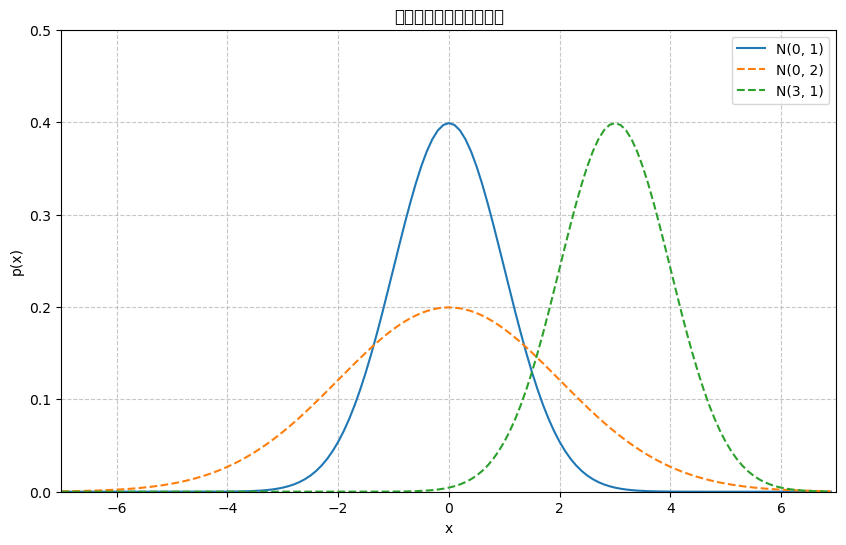

In [8]:
import matplotlib.pyplot as plt
x = np.arange(-7, 7, 0.1)
# 均值和标准差的组合
params = [(0, 1), (0, 2), (3, 1)]
normal_vec = np.vectorize(normal) # 向量化函数，可以传入x数组
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # 蓝、橙、绿

plt.figure(figsize=(10, 6))

for i, (mu, sigma) in enumerate(params):
    y = normal_vec(x, mu, sigma)
    if mu == 0 and sigma == 1:
        linestyle = '-'
        label = 'N(0, 1)'
    else:
        linestyle = '--'
        label = f'N({mu}, {sigma})'
    plt.plot(x, y, color=colors[i], linestyle=linestyle, label=label)

plt.legend()
plt.title('不同参数的正态分布曲线')
plt.xlabel('x')
plt.ylabel('p(x)')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 设置范围
plt.xlim(-7, 7)
plt.ylim(0, 0.5)

# 显示图形
plt.show()